# PV Daily → Hourly Disaggregation
**Energy Data Hackdays 2026**

**Approach:**

For each day: 

1. pv_hourly says: 12:00 --> 3207 MWh, 13:00 --> 3760 MWh, ... Summe = 28'769 MWh


2. SFOE daily says: Total = 29'800 MWh


3. Factor = 29'800 / 28'769 = 1.036


4. Scaled hourly = 12:00 --> 3322 MWh, 13:00 --> 3895 MWh, ... Summe = 29'800 MWh

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('OK')

OK


## 1. Load Data

In [3]:
# SFOE Daily
sfoe = pd.read_csv('data/sfoe_daily_2024_2025.csv', parse_dates=['Date']).set_index('Date')
sfoe.index = pd.to_datetime(sfoe.index)
print(f'SFOE: {sfoe.index.min().date()} to {sfoe.index.max().date()} | {len(sfoe)} days')
sfoe.head(3)

SFOE: 2024-01-01 to 2025-12-31 | 731 days


,Flusskraft,Kernkraft,Photovoltaik,Speicherkraft,Thermische,Wind
Date,,,,,,
2024-01-01,34.8,71.2,5.3,16.4,10.1,1.0
2024-01-02,34.4,71.0,2.7,35.9,10.1,1.5
2024-01-03,36.7,70.8,5.6,26.3,10.1,1.3


In [4]:
# PV Hourly Profile (pv_hourly estimate)
# File is whitespace-separated, but the timestamp itself contains a space
# rsplit(None, 1) splits only at the LAST whitespace block -> timestamp left, value right
with open('data/sfoe_pv_hourly_2024_2025.csv') as f:
    lines = f.readlines()

rows = []
for line in lines[1:]:          # skip header
    line = line.strip()
    if not line:
        continue
    ts, val = line.rsplit(None, 1)
    rows.append({'timestamp': ts, 'pv_raw': float(val)})

pv = pd.DataFrame(rows)
pv['timestamp'] = pd.to_datetime(pv['timestamp'])
pv = pv.set_index('timestamp')

if pv.index.tz is not None:
    pv.index = pv.index.tz_convert('Europe/Zurich').tz_localize(None)

pv['pv_raw'] = pd.to_numeric(pv['pv_raw'], errors='coerce').fillna(0)
print(f'PV: {pv.index.min().date()} to {pv.index.max().date()} | {len(pv)} hours')
pv.head(3)

PV: 2024-01-01 to 2026-01-01 | 17544 hours


,pv_raw
timestamp,
2024-01-01 01:00:00,0.0
2024-01-01 02:00:00,0.0
2024-01-01 03:00:00,0.0


In [5]:
# ENTSO-E Hourly
entso = pd.read_csv('data/generation_per_type_24_25.csv', index_col=0)
entso.index = pd.to_datetime(entso.index, utc=True).tz_convert('Europe/Zurich').tz_localize(None)
print(f'ENTSO-E: {entso.index.min().date()} to {entso.index.max().date()} | {len(entso)} hours')
entso.head(3)

ENTSO-E: 2024-01-01 to 2025-12-30 | 17519 hours


,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Solar,Wind Onshore
2024-01-01 00:00:00,44.25,218.28,255.45,3023.2,0.0,43.00
2024-01-01 01:00:00,75.70,221.35,267.73,3021.5,0.0,38.09
2024-01-01 02:00:00,55.70,217.88,277.85,3021.3,0.0,35.19


## 2. Scaling
Scaling approach: for each day, compute `scale_factor = SFOE_daily / sum(pv_raw)`, then multiply each hour by that factor.

In [6]:
pv['date'] = pv.index.normalize()

daily_profile_sum  = pv.groupby('date')['pv_raw'].transform('sum')
sfoe_mwh           = sfoe['Photovoltaik'] * 1000        # GWh -> MWh
pv['sfoe_daily']   = pv['date'].map(sfoe_mwh)
pv['scale_factor'] = pv['sfoe_daily'] / daily_profile_sum
pv['pv_scaled']    = (pv['pv_raw'] * pv['scale_factor']).fillna(0)

print('Scaling done')
print(f'Max hourly value: {pv["pv_scaled"].max():.1f} MWh/h')
pv[['pv_raw', 'scale_factor', 'pv_scaled']].describe()

Scaling done
Max hourly value: 5949.9 MWh/h


,pv_raw,scale_factor,pv_scaled
count,17544.000000,17543.000000,17544.000000
mean,819.052881,1.027034,805.876653
std,1311.374430,0.265820,1271.258759
min,0.000000,0.115114,0.000000
25%,0.000000,0.946443,0.000000
50%,39.919582,0.994785,41.288163
75%,1183.619158,1.058954,1214.809477
max,6320.540711,3.674899,5949.902074


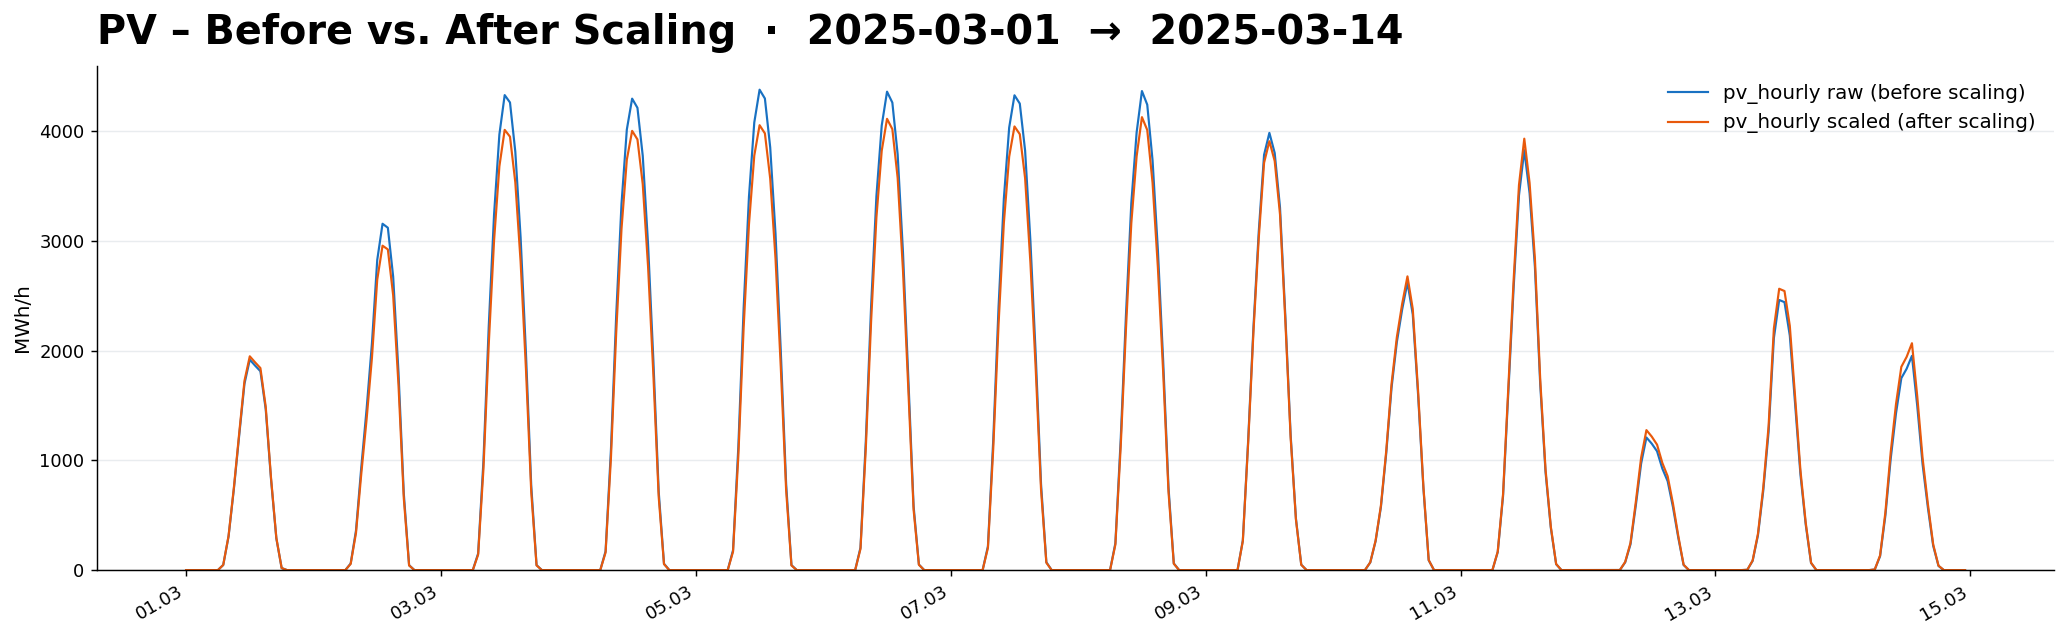

In [7]:
PERIOD_START = '2025-03-01'
PERIOD_END   = '2025-03-14'

pv_period   = pv.loc[PERIOD_START:PERIOD_END]
sfoe_period = sfoe_mwh.loc[PERIOD_START:PERIOD_END]

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(pv_period.index, pv_period['pv_raw'],
        color='#1971c2', lw=1.2, label='pv_hourly raw (before scaling)')
ax.plot(pv_period.index, pv_period['pv_scaled'],
        color='#e8590c', lw=1.2, label='pv_hourly scaled (after scaling)')

#for j, (date, val) in enumerate(sfoe_period.items()):
#    ax.hlines(val/24, date, date + pd.Timedelta(hours=23),
#              colors='#e03131', lw=1, ls='--',
#              label='SFOE daily avg (÷24)' if j == 0 else '')

ax.set_title(f'PV – Before vs. After Scaling  ·  {PERIOD_START}  →  {PERIOD_END}',
             fontweight='bold', fontsize=22, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Validation

In [8]:
result_gwh = pv.groupby('date')['pv_scaled'].sum() / 1000
common     = result_gwh.index.intersection(sfoe['Photovoltaik'].index)
diff       = (result_gwh[common] - sfoe['Photovoltaik'][common]).abs()

print(f'Common days:      {len(common)}')
print(f'Max deviation:    {diff.max():.6f} GWh  (target: ~0)')
print(f'Mean deviation:   {diff.mean():.8f} GWh')

Common days:      731
Max deviation:    0.000000 GWh  (target: ~0)
Mean deviation:   0.00000000 GWh


## 4. Visualisations

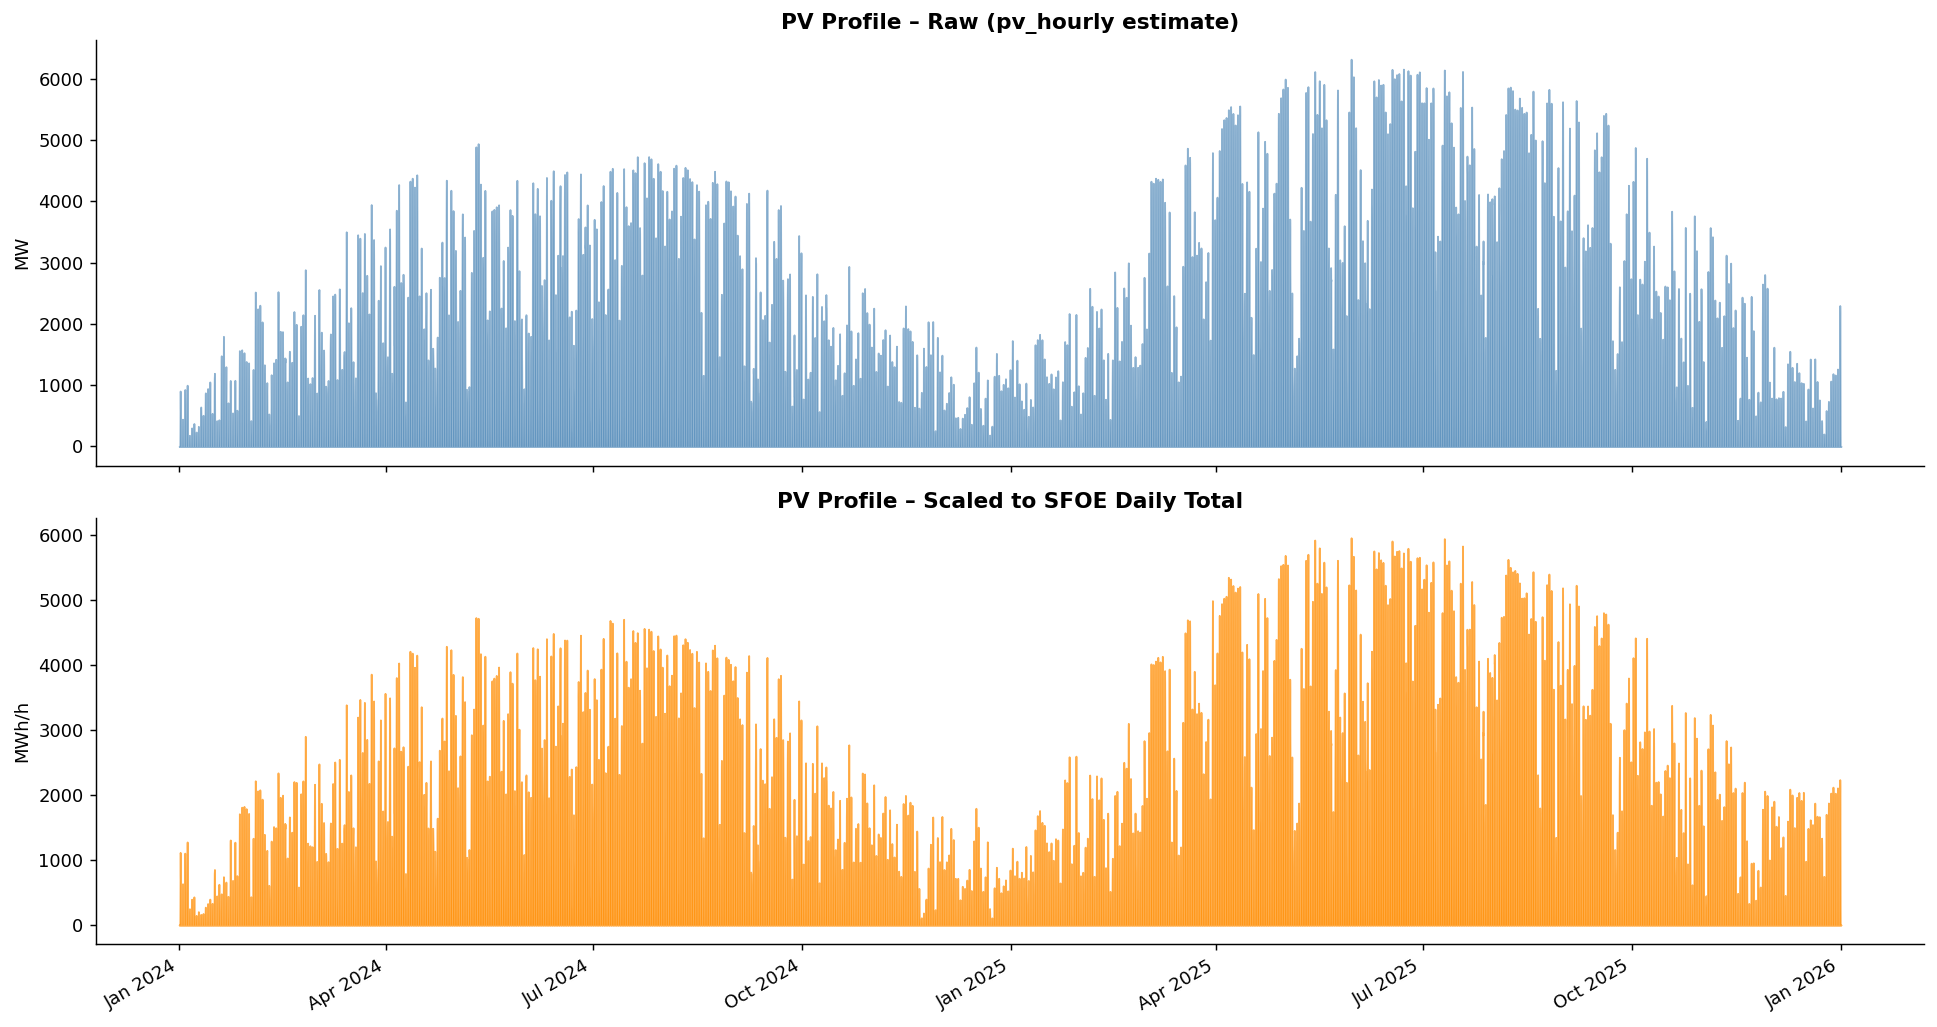

In [9]:
# Plot 1: Annual overview raw vs. scaled
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].fill_between(pv.index, pv['pv_raw'], color='steelblue', alpha=0.6)
axes[0].set_title('PV Profile – Raw (pv_hourly estimate)', fontweight='bold')
axes[0].set_ylabel('MW')
axes[1].fill_between(pv.index, pv['pv_scaled'], color='darkorange', alpha=0.7)
axes[1].set_title('PV Profile – Scaled to SFOE Daily Total', fontweight='bold')
axes[1].set_ylabel('MWh/h')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

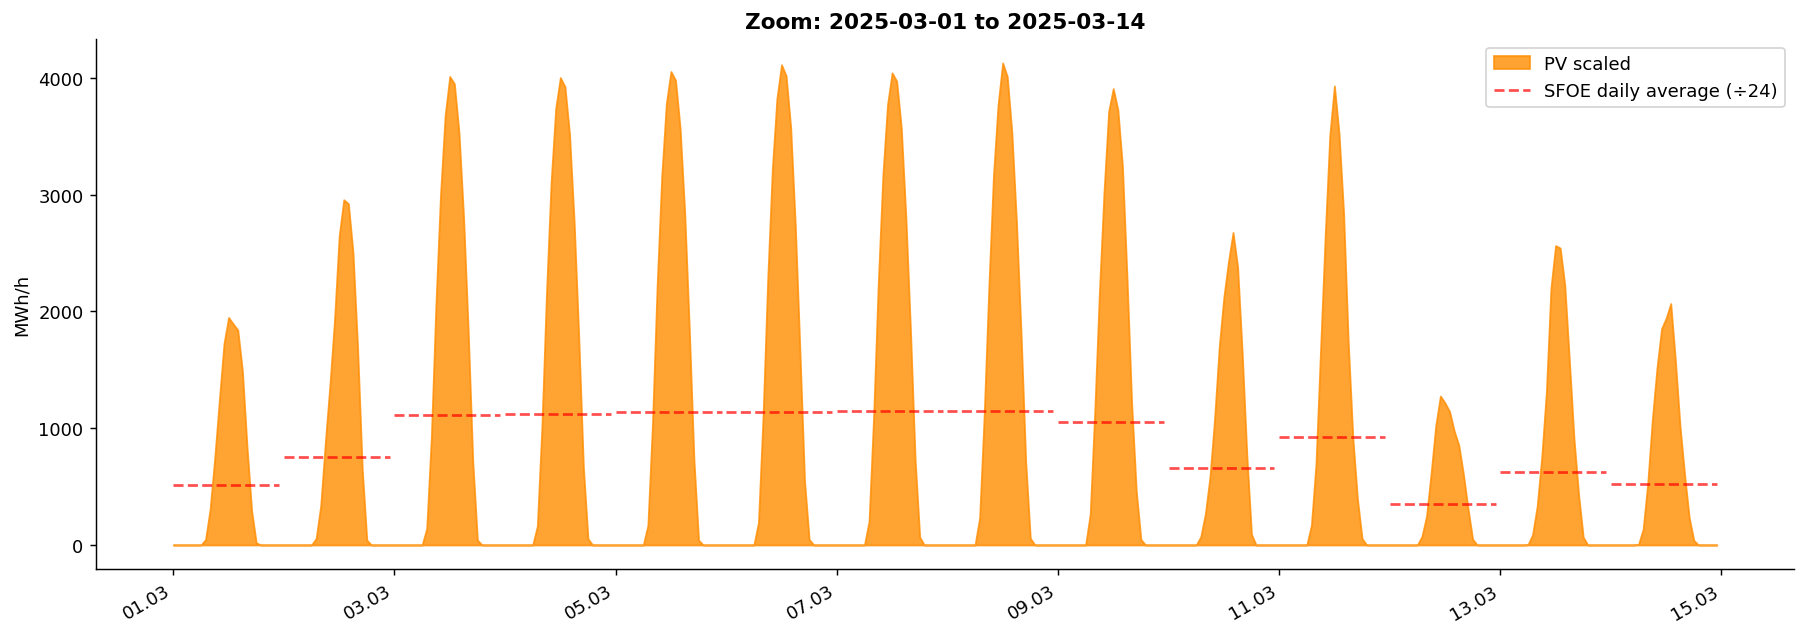

In [10]:
# Plot 2: 2-week zoom
ZOOM_START = '2025-03-01'
ZOOM_END   = '2025-03-14'

pv_z = pv[ZOOM_START:ZOOM_END]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(pv_z.index, pv_z['pv_scaled'], color='darkorange', alpha=0.8, label='PV scaled')
sfoe_z = sfoe_mwh[ZOOM_START:ZOOM_END]
for i, (date, val) in enumerate(sfoe_z.items()):
    ax.hlines(val/24, date, date + pd.Timedelta(hours=23),
              colors='red', lw=1.5, ls='--', alpha=0.7,
              label='SFOE daily average (÷24)' if i == 0 else '')
ax.set_title(f'Zoom: {ZOOM_START} to {ZOOM_END}', fontweight='bold')
ax.set_ylabel('MWh/h')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

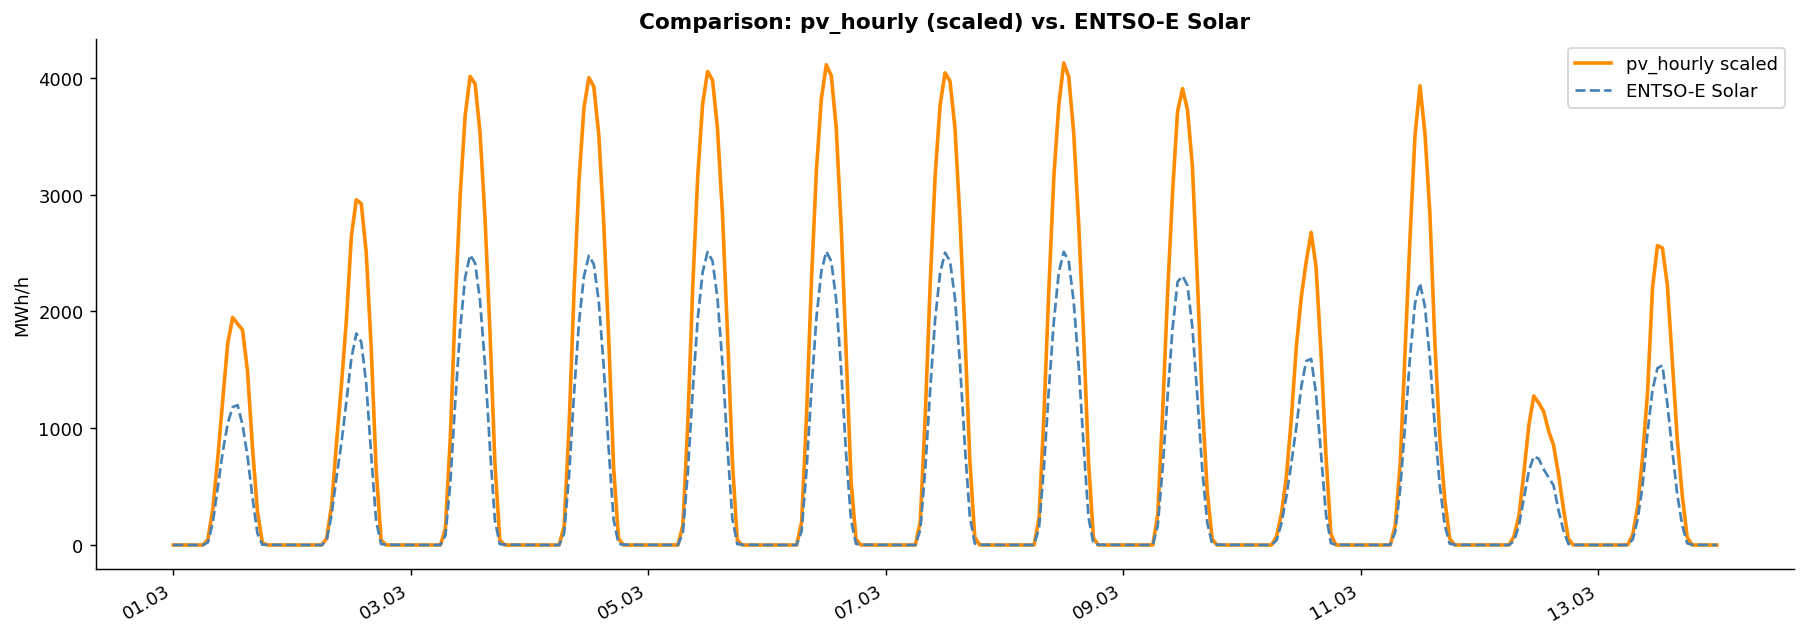

In [11]:
# Plot 3: Comparison pv_hourly scaled vs. ENTSO-E Solar
idx_common = pv.index.intersection(entso.index)
mask_z     = (idx_common >= ZOOM_START) & (idx_common <= ZOOM_END)
idx_z      = idx_common[mask_z]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx_z, pv.loc[idx_z, 'pv_scaled'], color='darkorange', lw=2,   label='pv_hourly scaled')
ax.plot(idx_z, entso.loc[idx_z, 'Solar'],  color='steelblue',  lw=1.5, ls='--', label='ENTSO-E Solar')
ax.set_title('Comparison: pv_hourly (scaled) vs. ENTSO-E Solar', fontweight='bold')
ax.set_ylabel('MWh/h')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

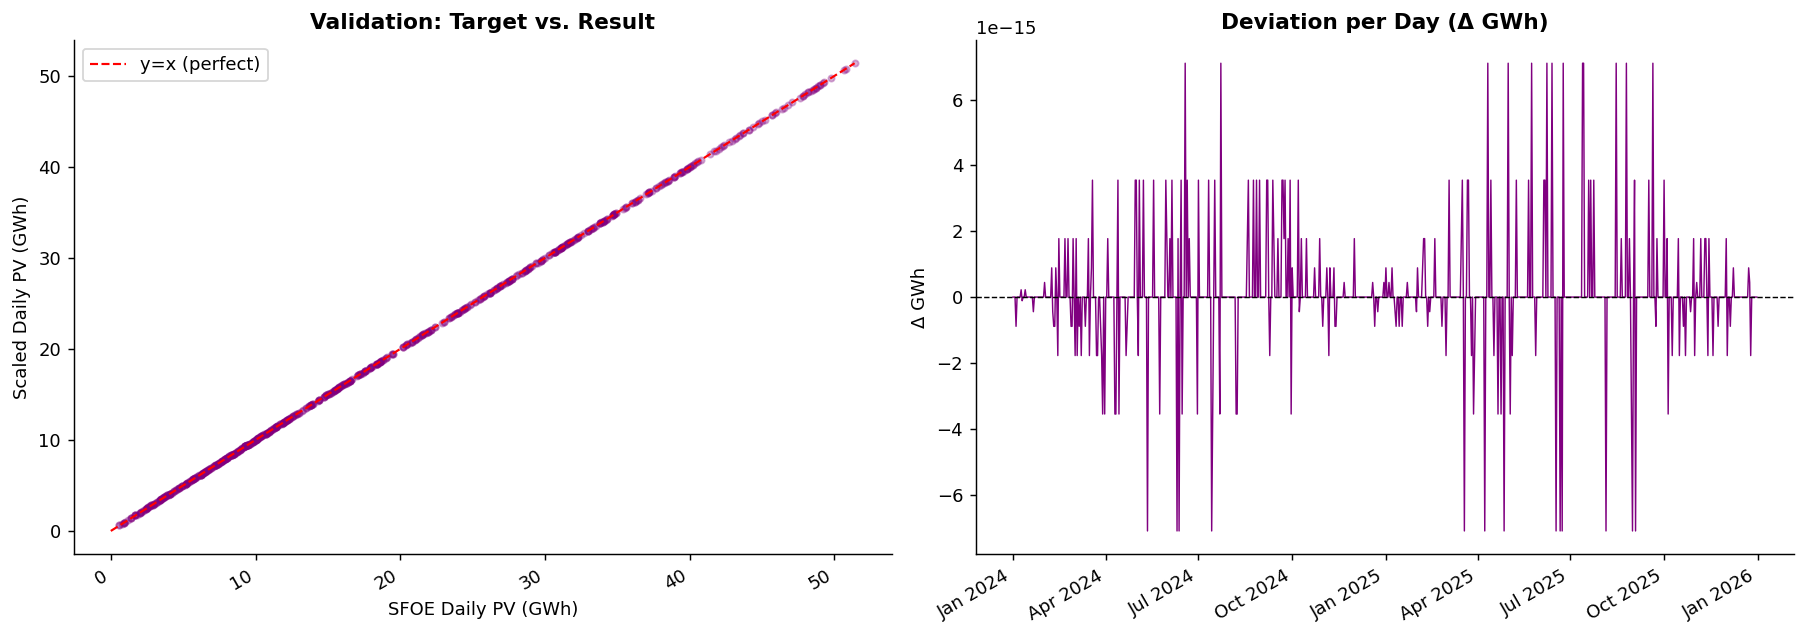

In [12]:
# Plot 4: Validation scatter + daily deviation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(sfoe['Photovoltaik'][common], result_gwh[common], alpha=0.3, s=12, color='purple')
lim = [0, sfoe['Photovoltaik'][common].max()]
axes[0].plot(lim, lim, 'r--', lw=1.2, label='y=x (perfect)')
axes[0].set_xlabel('SFOE Daily PV (GWh)')
axes[0].set_ylabel('Scaled Daily PV (GWh)')
axes[0].set_title('Validation: Target vs. Result', fontweight='bold')
axes[0].legend()
diff_signed = result_gwh[common] - sfoe['Photovoltaik'][common]
axes[1].plot(common, diff_signed, color='purple', lw=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Deviation per Day (Δ GWh)', fontweight='bold')
axes[1].set_ylabel('Δ GWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

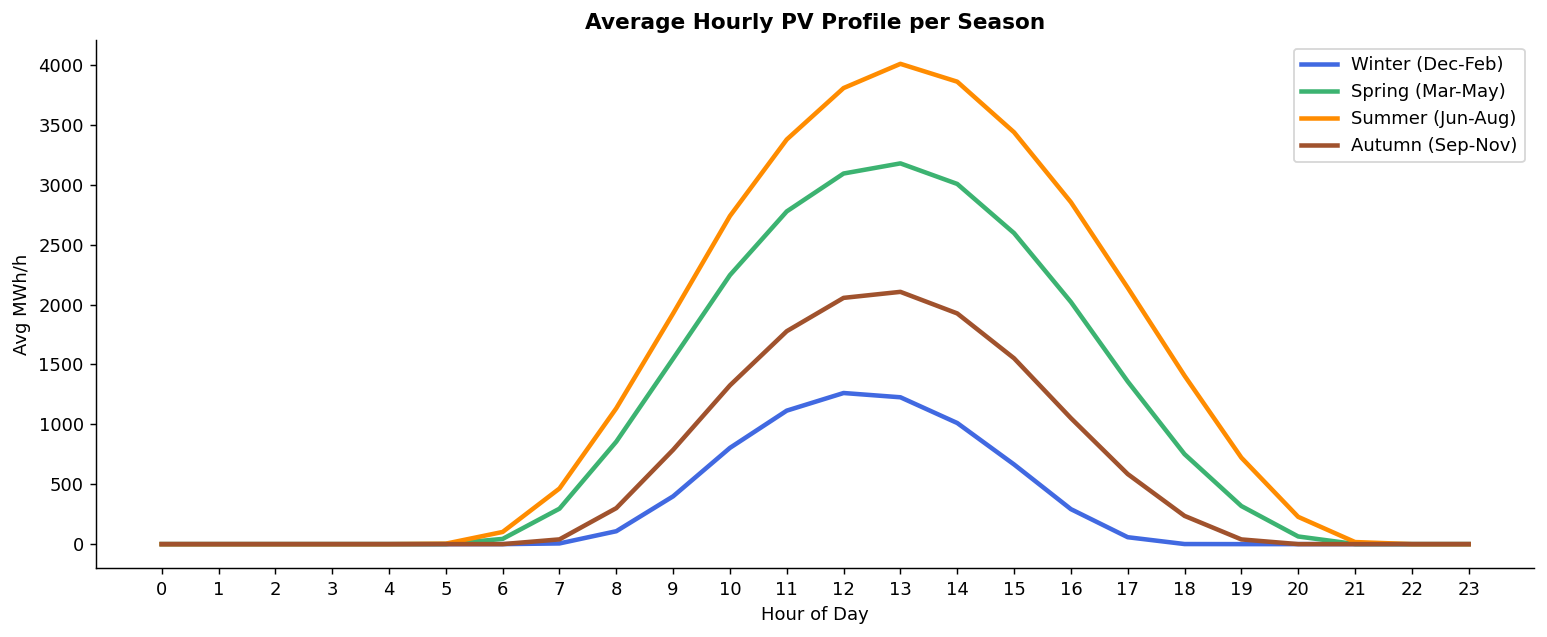

In [13]:
# Plot 5: Average daily profile per season
pv['month'] = pv.index.month
pv['hour']  = pv.index.hour
seasons = {
    'Winter (Dec-Feb)':   [12, 1, 2],
    'Spring (Mar-May)':   [3, 4, 5],
    'Summer (Jun-Aug)':   [6, 7, 8],
    'Autumn (Sep-Nov)':   [9, 10, 11]
}
colors = ['royalblue', 'mediumseagreen', 'darkorange', 'sienna']
fig, ax = plt.subplots(figsize=(12, 5))
for (season, months), color in zip(seasons.items(), colors):
    profile = pv[pv['month'].isin(months)].groupby('hour')['pv_scaled'].mean()
    ax.plot(profile.index, profile.values, label=season, color=color, lw=2.5)
ax.set_title('Average Hourly PV Profile per Season', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg MWh/h')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Scaling – Other Production Types
Same approach as PV: use ENTSO-E hourly profile as shape, scale to SFOE daily total.

| SFOE | ENTSO-E profile |
|---|---|
| Photovoltaik | sfoe_pv_hourly (already done) |
| Flusskraft | Hydro Run-of-river and poundage |
| Kernkraft | Nuclear (linear → flat distribution) |
| Speicherkraft | Hydro Pumped Storage + Hydro Water Reservoir |
| Wind | Wind Onshore |

In [14]:
def scale_to_sfoe(entso_profile, sfoe_daily_col, label):
    """
    Scale an hourly ENTSO-E profile to match SFOE daily totals.
    entso_profile : pd.Series with hourly values (MWh)
    sfoe_daily_col: pd.Series with daily totals in GWh
    label         : string name for output column
    """
    df = entso_profile.to_frame(name='raw').copy()
    df['date'] = df.index.normalize()

    daily_sum      = df.groupby('date')['raw'].transform('sum')
    sfoe_mwh_daily = sfoe_daily_col * 1000                     # GWh -> MWh
    df['sfoe']     = df['date'].map(sfoe_mwh_daily)
    df['factor']   = df['sfoe'] / daily_sum
    df['scaled']   = (df['raw'] * df['factor']).fillna(0)

    # Validation
    result  = df.groupby('date')['scaled'].sum() / 1000
    common  = result.index.intersection(sfoe_daily_col.index)
    maxdiff = (result[common] - sfoe_daily_col[common]).abs().max()
    print(f'{label:20s} | max deviation: {maxdiff:.6f} GWh')

    return df['scaled'].rename(label)

print('scale_to_sfoe() ready')

scale_to_sfoe() ready


In [15]:
# 5.1 Flusskraft → Hydro Run-of-river and poundage
flusskraft_scaled = scale_to_sfoe(
    entso['Hydro Run-of-river and poundage'],
    sfoe['Flusskraft'],
    'Flusskraft'
)

# 5.2 Kernkraft → Nuclear (nearly flat by nature)
kernkraft_scaled = scale_to_sfoe(
    entso['Nuclear'],
    sfoe['Kernkraft'],
    'Kernkraft'
)

# 5.3 Speicherkraft → Hydro Pumped Storage + Hydro Water Reservoir
speicher_profile = entso['Hydro Pumped Storage'] + entso['Hydro Water Reservoir']
speicherkraft_scaled = scale_to_sfoe(
    speicher_profile,
    sfoe['Speicherkraft'],
    'Speicherkraft'
)

# 5.4 Wind → Wind Onshore
wind_scaled = scale_to_sfoe(
    entso['Wind Onshore'],
    sfoe['Wind'],
    'Wind'
)

# 5.5 Thermische → flat distribution (daily total / 24)
# No hourly profile available, distribute evenly across all hours of each day
sfoe_therm_mwh = sfoe['Thermische'] * 1000  # GWh -> MWh
pv_dates = pv.index.normalize()
thermische_hourly = pd.Series(
    pv_dates.map(sfoe_therm_mwh) / 24,
    index=pv.index
).fillna(0)
thermische_hourly.name = 'Thermische'

# Validation
result_t  = thermische_hourly.groupby(thermische_hourly.index.normalize()).sum() / 1000
common_t  = result_t.index.intersection(sfoe['Thermische'].index)
maxdiff_t = (result_t[common_t] - sfoe['Thermische'][common_t]).abs().max()
print(f'Thermische           | max deviation: {maxdiff_t:.6f} GWh')

Flusskraft           | max deviation: 0.000000 GWh
Kernkraft            | max deviation: 0.000000 GWh
Speicherkraft        | max deviation: 0.000000 GWh
Wind                 | max deviation: 0.000000 GWh
Thermische           | max deviation: 0.433333 GWh


## 6. Merge All Production Types

In [16]:
# Combine all scaled hourly series into one DataFrame
# Deduplicate index first (can occur due to DST clock changes)
def dedup(s):
    return s[~s.index.duplicated(keep='first')]

final = pd.DataFrame({
    'Photovoltaik':  dedup(pv['pv_scaled']),
    'Flusskraft':    dedup(flusskraft_scaled),
    'Kernkraft':     dedup(kernkraft_scaled),
    'Speicherkraft': dedup(speicherkraft_scaled),
    'Wind':          dedup(wind_scaled),
    'Thermische':    dedup(thermische_hourly),
})

# Only keep rows where all types have data
final = final.dropna()
final['Total'] = final.sum(axis=1)

print(f'Final dataset: {final.index.min().date()} to {final.index.max().date()} | {len(final)} hours')
final.describe()

Final dataset: 2024-01-01 to 2025-12-30 | 17516 hours


,Photovoltaik,Flusskraft,Kernkraft,Speicherkraft,Wind,Thermische,Total
count,17516.000000,17516.000000,17516.000000,17516.000000,17516.000000,17516.000000,17516.000000
mean,806.514044,2038.270656,2358.292939,2851.661858,18.393674,411.420987,8484.554159
std,1271.833818,792.802089,660.118268,2101.979809,16.552122,28.485416,2481.184435
min,0.000000,409.955781,177.967069,133.402726,0.000000,362.500000,3343.510227
25%,0.000000,1394.558454,1854.794024,1048.629413,5.823333,383.333333,6445.308323
50%,41.558698,1879.556736,2576.563722,2224.014351,12.464658,408.333333,8342.387387
75%,1216.294136,2603.858396,2951.060757,4345.295303,26.543469,433.333333,10227.115489
max,5949.902074,14716.252870,3766.219372,10475.040641,96.657328,462.500000,19574.122437


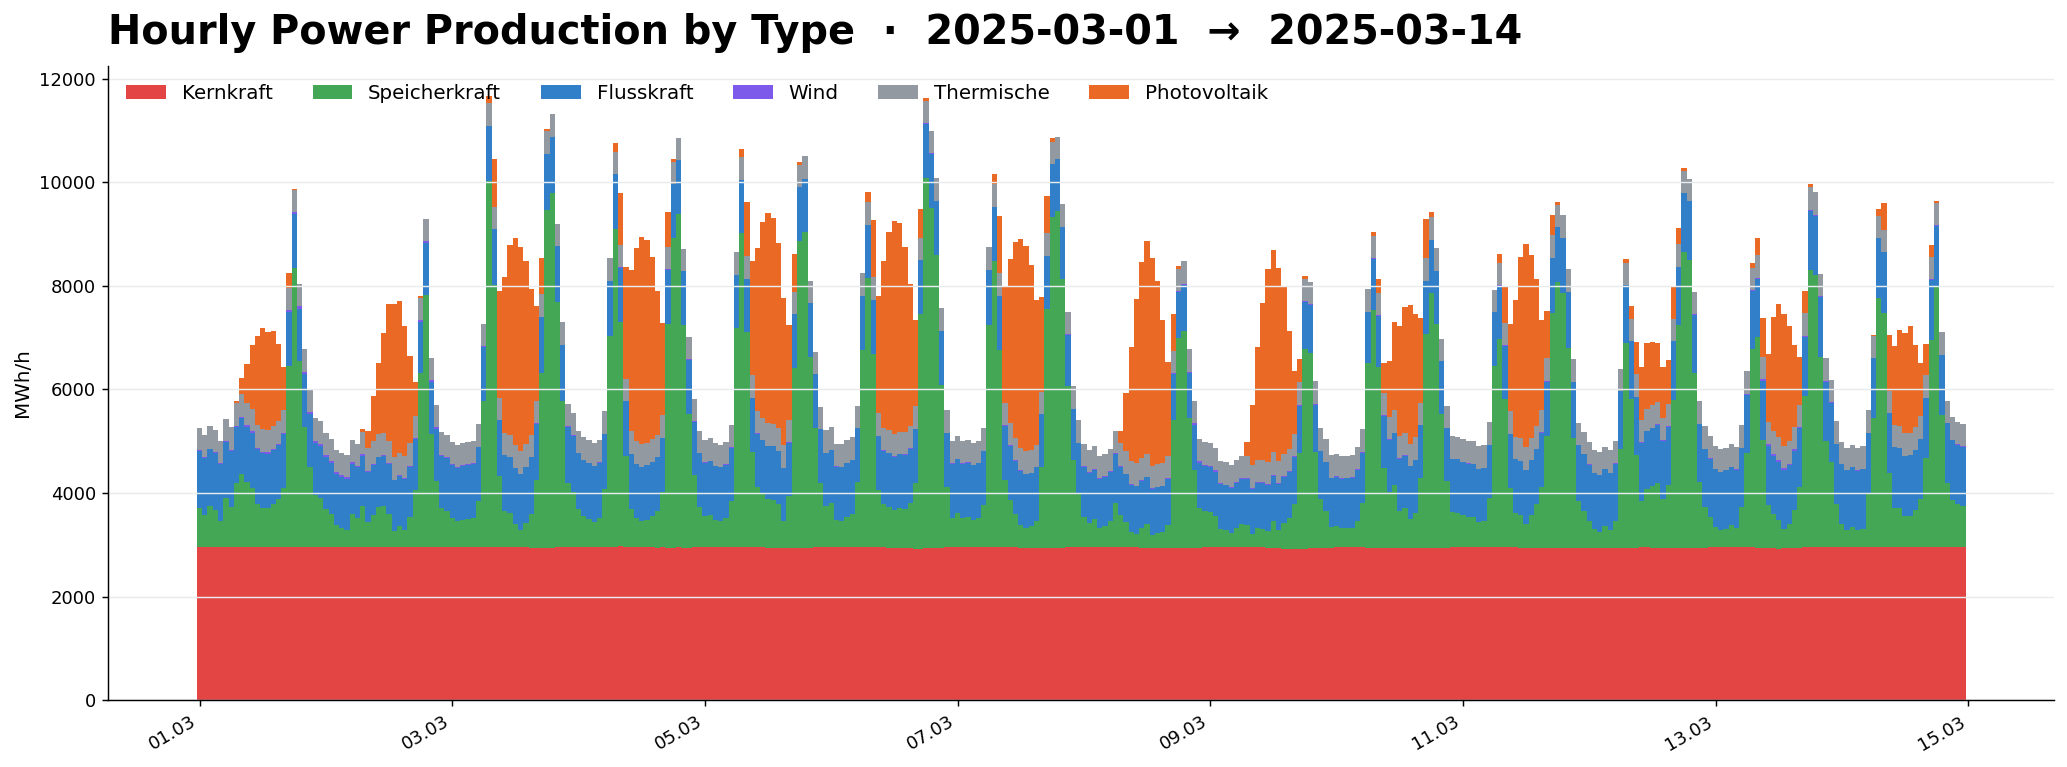

In [17]:
BAR_START = '2025-03-01'
BAR_END   = '2025-03-14'

final_z = final.loc[BAR_START:BAR_END]
cols    = ['Kernkraft', 'Speicherkraft', 'Flusskraft', 'Wind', 'Thermische', 'Photovoltaik']
colors  = ['#e03131', '#2f9e44', '#1971c2', '#7048e8', '#868e96', '#e8590c']

fig, ax = plt.subplots(figsize=(16, 6))

bottom = pd.Series(0, index=final_z.index)
for col, color in zip(cols, colors):
    ax.bar(final_z.index, final_z[col], bottom=bottom,
           label=col, color=color, alpha=0.9, width=pd.Timedelta(hours=1))
    bottom += final_z[col]

ax.set_title(f'Hourly Power Production by Type  ·  {BAR_START}  →  {BAR_END}',
             fontweight='bold', fontsize=22, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8, zorder=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False, loc='upper left',
          ncol=len(cols))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

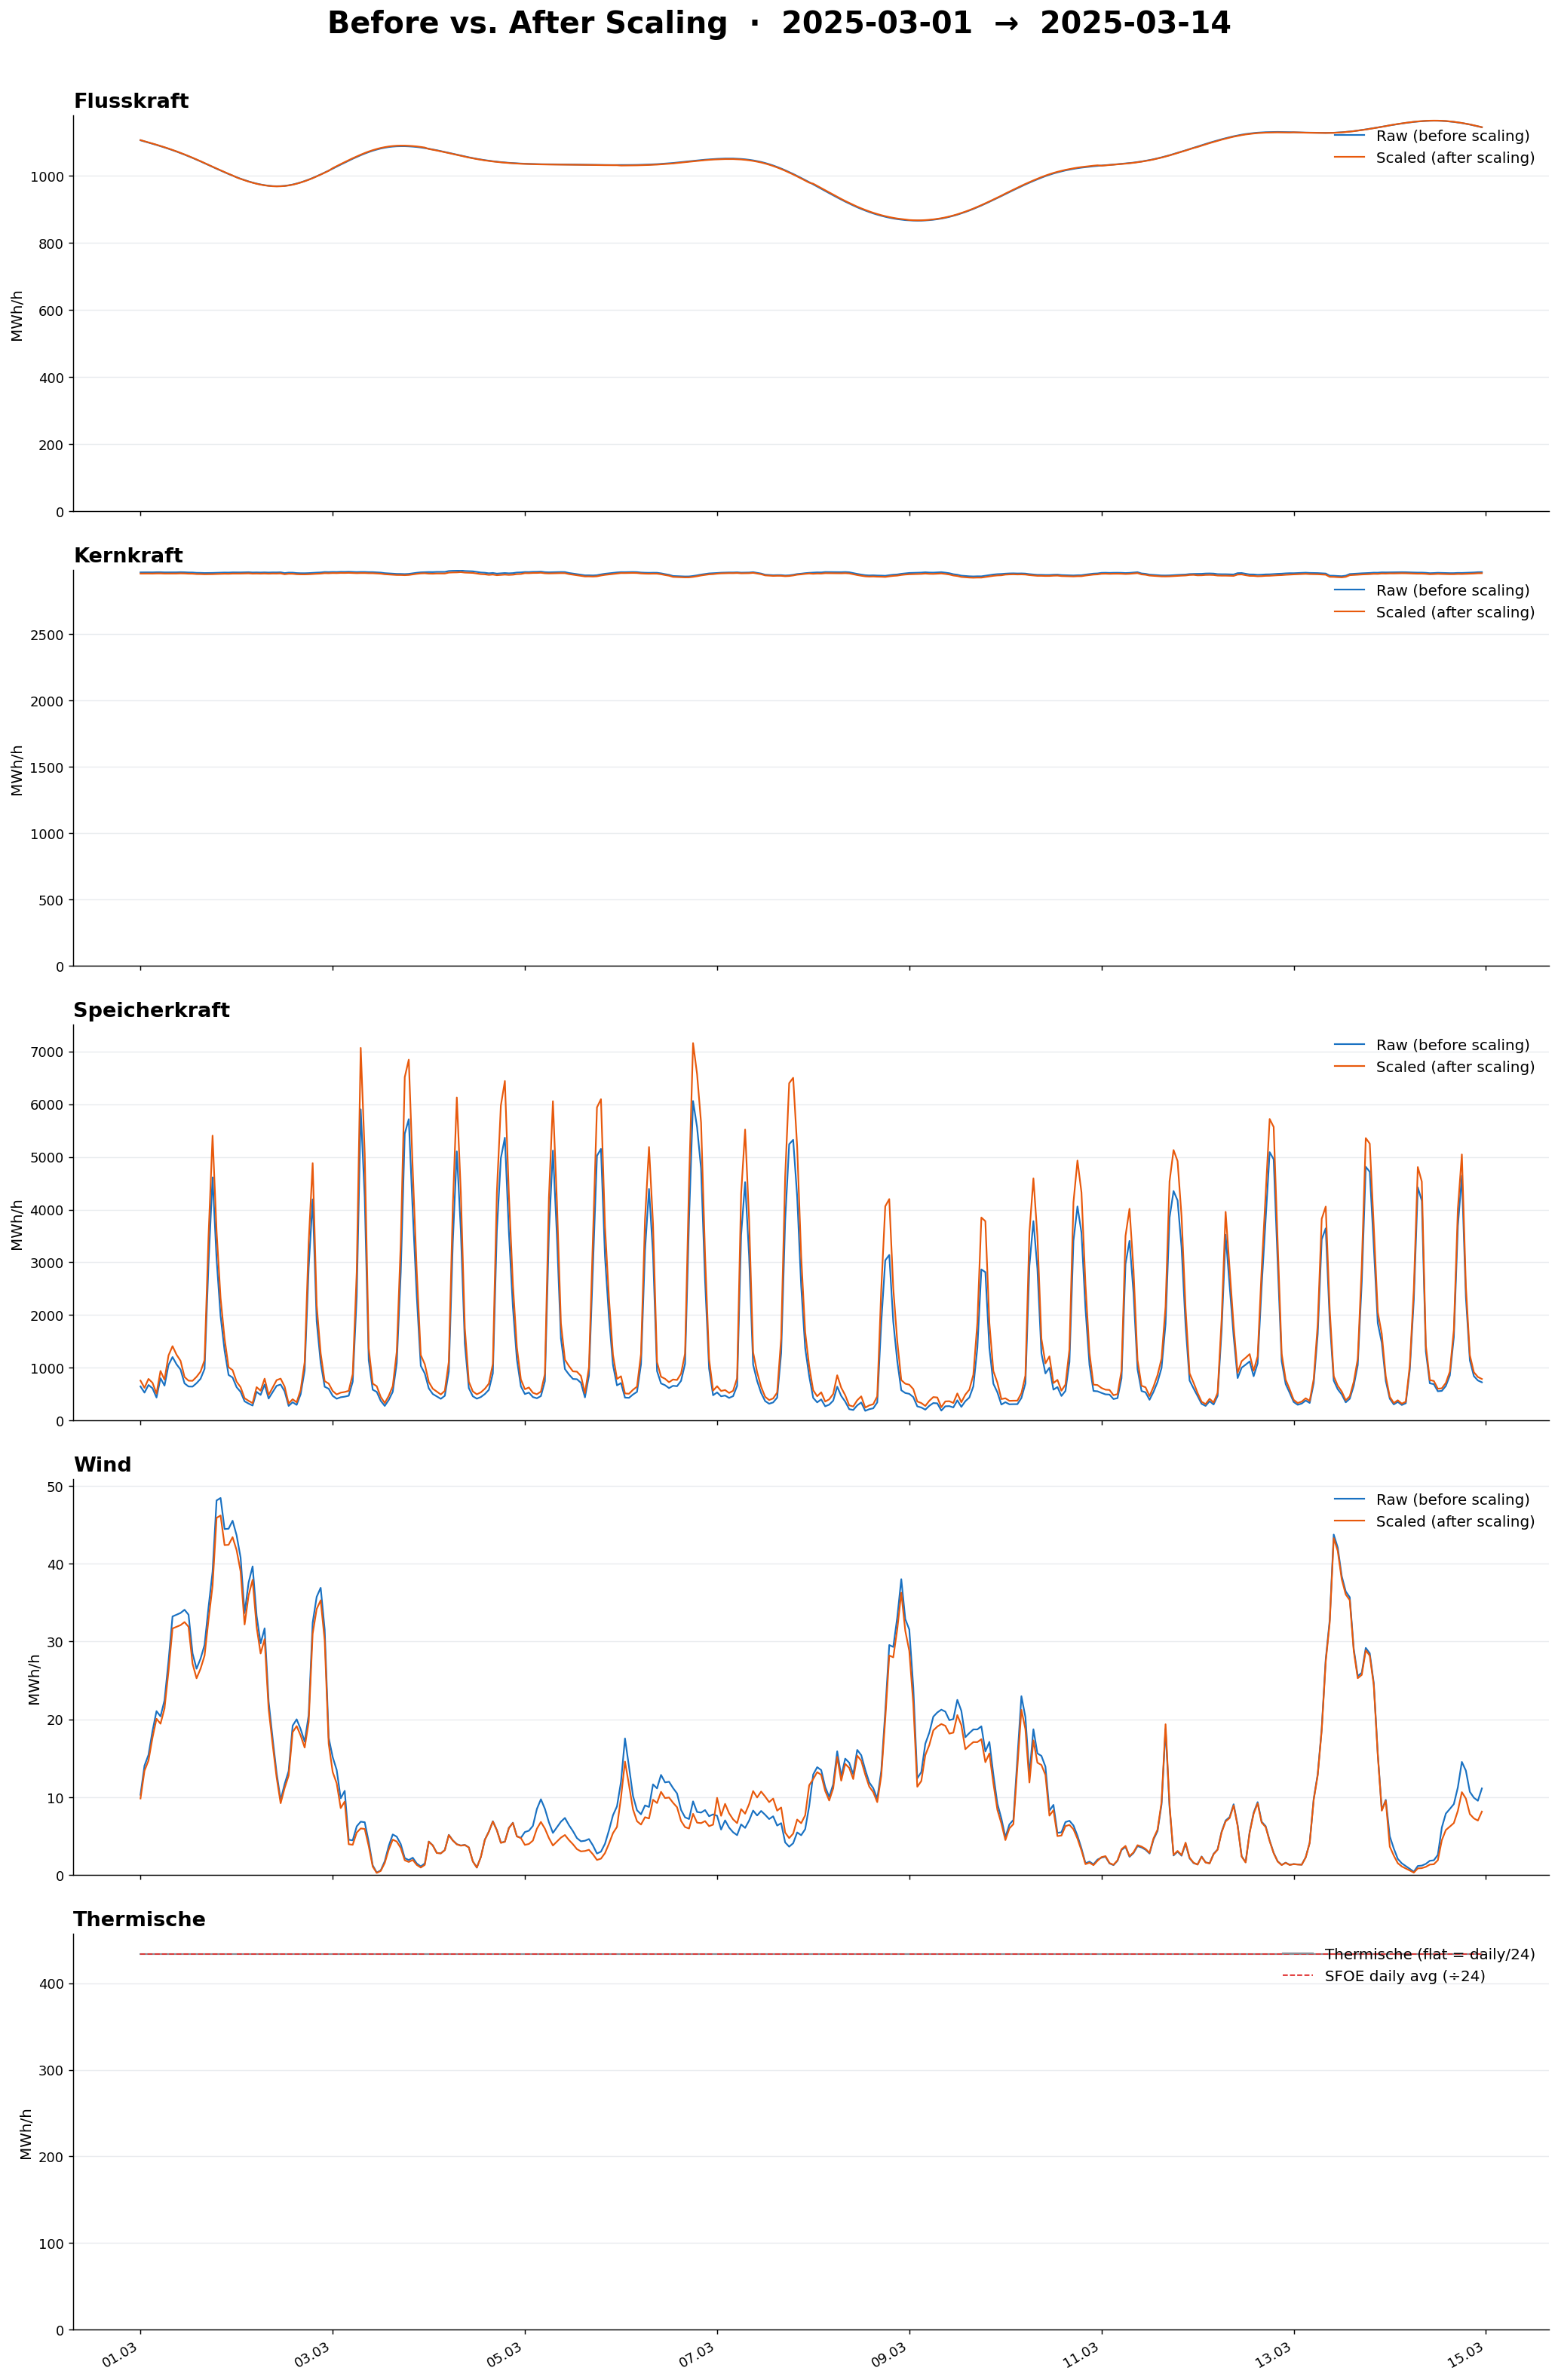

In [18]:
# Plot: Before vs. After – all types, 8-day zoom
ZOOM_S = '2025-03-01'
ZOOM_E = '2025-03-14'

type_map = {
    'Flusskraft':    (entso['Hydro Run-of-river and poundage'], flusskraft_scaled),
    'Kernkraft':     (entso['Nuclear'],                         kernkraft_scaled),
    'Speicherkraft': (entso['Hydro Pumped Storage'] + entso['Hydro Water Reservoir'], speicherkraft_scaled),
    'Wind':          (entso['Wind Onshore'],                    wind_scaled),
}

COLORS = {
    'raw':    '#1971c2',
    'scaled': '#e8590c',
    'sfoe':   '#e03131',
    'therm':  '#868e96',
}

fig, axes = plt.subplots(5, 1, figsize=(16, 24), sharex=True)

for ax, (label, (raw, scaled)) in zip(axes[:4], type_map.items()):
    raw_z    = raw.loc[ZOOM_S:ZOOM_E]
    scaled_z = scaled.loc[ZOOM_S:ZOOM_E]

    ax.plot(raw_z.index,    raw_z.values,    color=COLORS['raw'],    lw=1.2, label='Raw (before scaling)')
    ax.plot(scaled_z.index, scaled_z.values, color=COLORS['scaled'], lw=1.2, label='Scaled (after scaling)')

    # for j, (date, val) in enumerate(sfoe[label].loc[ZOOM_S:ZOOM_E].items()):
    #     ax.hlines(val*1000/24, date, date + pd.Timedelta(hours=23),
    #               colors=COLORS['sfoe'], lw=1, ls='--',
    #               label='SFOE daily avg (÷24)' if j == 0 else '')

    ax.set_title(label, fontweight='bold', fontsize=15, loc='left')
    ax.set_ylabel('MWh/h', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=11, frameon=False, loc='upper right')

ax5 = axes[4]
therm_z = thermische_hourly.loc[ZOOM_S:ZOOM_E]
ax5.plot(therm_z.index, therm_z.values, color=COLORS['therm'], lw=1.2,
         label='Thermische (flat = daily/24)')
for j, (date, val) in enumerate(sfoe['Thermische'].loc[ZOOM_S:ZOOM_E].items()):
    ax5.hlines(val*1000/24, date, date + pd.Timedelta(hours=23),
               colors=COLORS['sfoe'], lw=1, ls='--',
               label='SFOE daily avg (÷24)' if j == 0 else '')
ax5.set_title('Thermische', fontweight='bold', fontsize=15, loc='left')
ax5.set_ylabel('MWh/h', fontsize=11)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax5.set_ylim(bottom=0)
ax5.legend(fontsize=11, frameon=False, loc='upper right')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
fig.suptitle(f'Before vs. After Scaling  ·  {ZOOM_S}  →  {ZOOM_E}',
             fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=2)
plt.show()

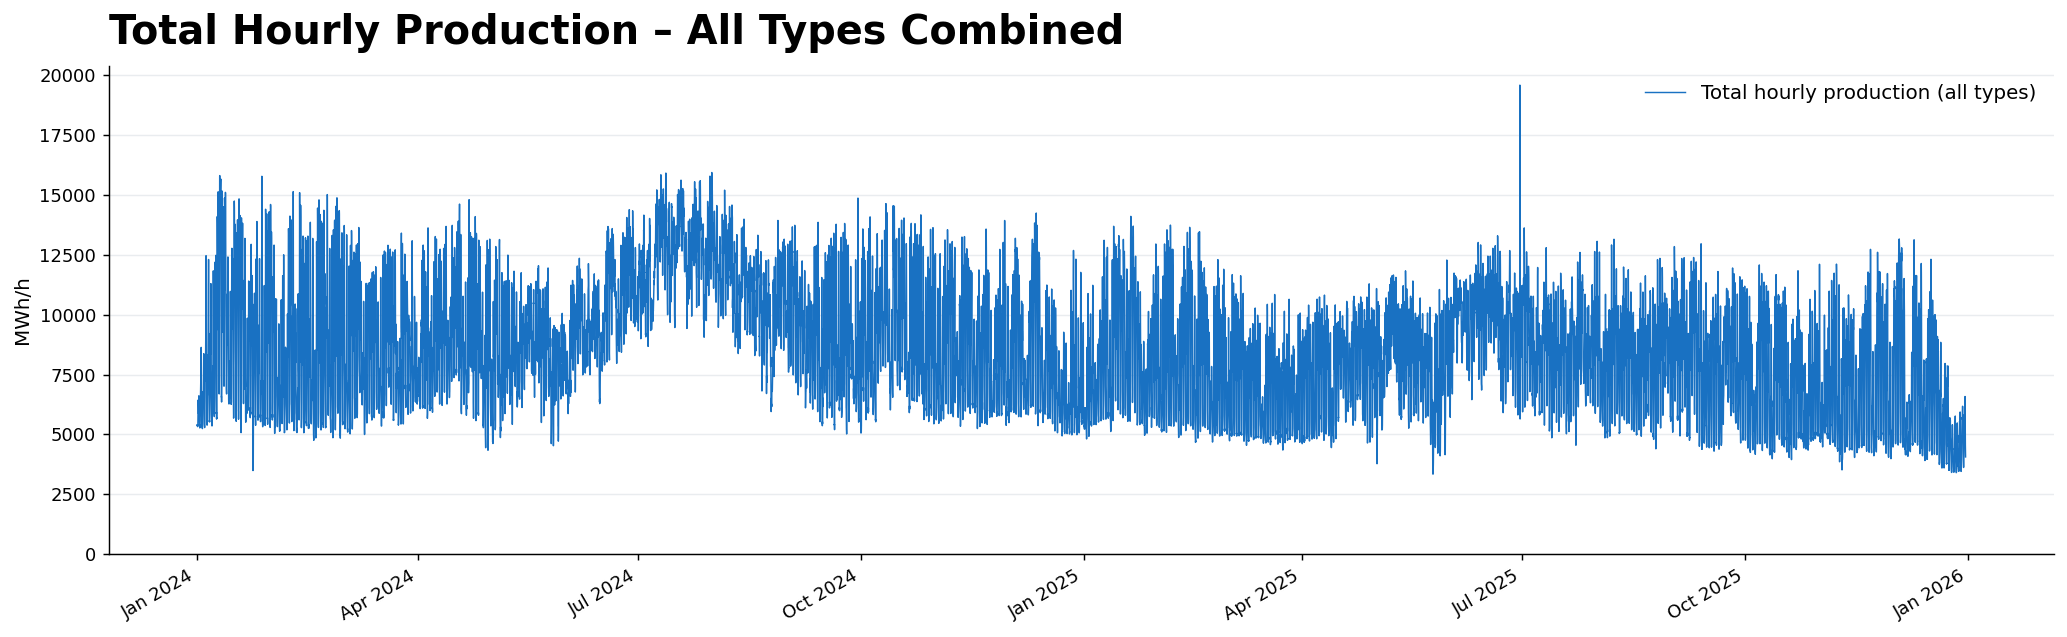

Total production range: 3344 – 19574 MWh/h
Total production mean:  8485 MWh/h


In [19]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(final.index, final['Total'],
        color='#1971c2', lw=0.8, label='Total hourly production (all types)')

ax.set_title('Total Hourly Production – All Types Combined',
             fontweight='bold', fontsize=22, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f'Total production range: {final["Total"].min():.0f} – {final["Total"].max():.0f} MWh/h')
print(f'Total production mean:  {final["Total"].mean():.0f} MWh/h')

## 8. Swissgrid Comparison

In [20]:
# Load Swissgrid 15-min data
sg_raw = pd.read_excel('data/swissgrid.xlsx', sheet_name='Zeitreihen0h15')

# Parse timestamp (format: DD.MM.YYYY HH:MM)
sg_raw['timestamp'] = pd.to_datetime(sg_raw['Zeitstempel'], format='%d.%m.%Y %H:%M')
sg_raw = sg_raw.set_index('timestamp')

# kWh → MWh, then resample 15min → hourly (sum 4 quarters = 1 hour)
sg_raw['produced_energy_MWh'] = sg_raw['produced_energy_kWh'] / 1000
swissgrid = sg_raw['produced_energy_MWh'].resample('h').sum()

print(f'Swissgrid: {swissgrid.index.min().date()} to {swissgrid.index.max().date()} | {len(swissgrid)} hours')
print(f'Hourly range: {swissgrid.min():.0f} – {swissgrid.max():.0f} MWh/h')
swissgrid.head()

Swissgrid: 2025-01-01 to 2025-12-31 | 8760 hours
Hourly range: 0 – 13492 MWh/h


timestamp
2025-01-01 00:00:00    5312.450869
2025-01-01 01:00:00    4924.261701
2025-01-01 02:00:00    4915.613285
2025-01-01 03:00:00    4741.327391
2025-01-01 04:00:00    4738.819612
Freq: h, Name: produced_energy_MWh, dtype: float64

In [21]:
# Export aggregated Swissgrid (15min → hourly, kWh → MWh)
swissgrid.to_frame(name='produced_energy_MWh').to_csv('data/swissgrid_hourly_mwh.csv')
print(f'Saved: data/swissgrid_hourly_mwh.csv  ({len(swissgrid)} rows)')
swissgrid.head()

Saved: data/swissgrid_hourly_mwh.csv  (8760 rows)


timestamp
2025-01-01 00:00:00    5312.450869
2025-01-01 01:00:00    4924.261701
2025-01-01 02:00:00    4915.613285
2025-01-01 03:00:00    4741.327391
2025-01-01 04:00:00    4738.819612
Freq: h, Name: produced_energy_MWh, dtype: float64

In [22]:
# Align both datasets on common time index
common_idx = final.index.intersection(swissgrid.index)
our_total  = final.loc[common_idx, 'Total']
sg_total   = swissgrid.loc[common_idx]

diff = our_total - sg_total

print(f'Common hours:    {len(common_idx)}')
print(f'Mean diff:       {diff.mean():.0f} MWh/h')
print(f'MAE:             {diff.abs().mean():.0f} MWh/h')
print(f'Max diff:        {diff.abs().max():.0f} MWh/h')
print(f'Our mean total:  {our_total.mean():.0f} MWh/h')
print(f'SG mean total:   {sg_total.mean():.0f} MWh/h')

Common hours:    8734
Mean diff:       687 MWh/h
MAE:             737 MWh/h
Max diff:        11922 MWh/h
Our mean total:  7737 MWh/h
SG mean total:   7050 MWh/h


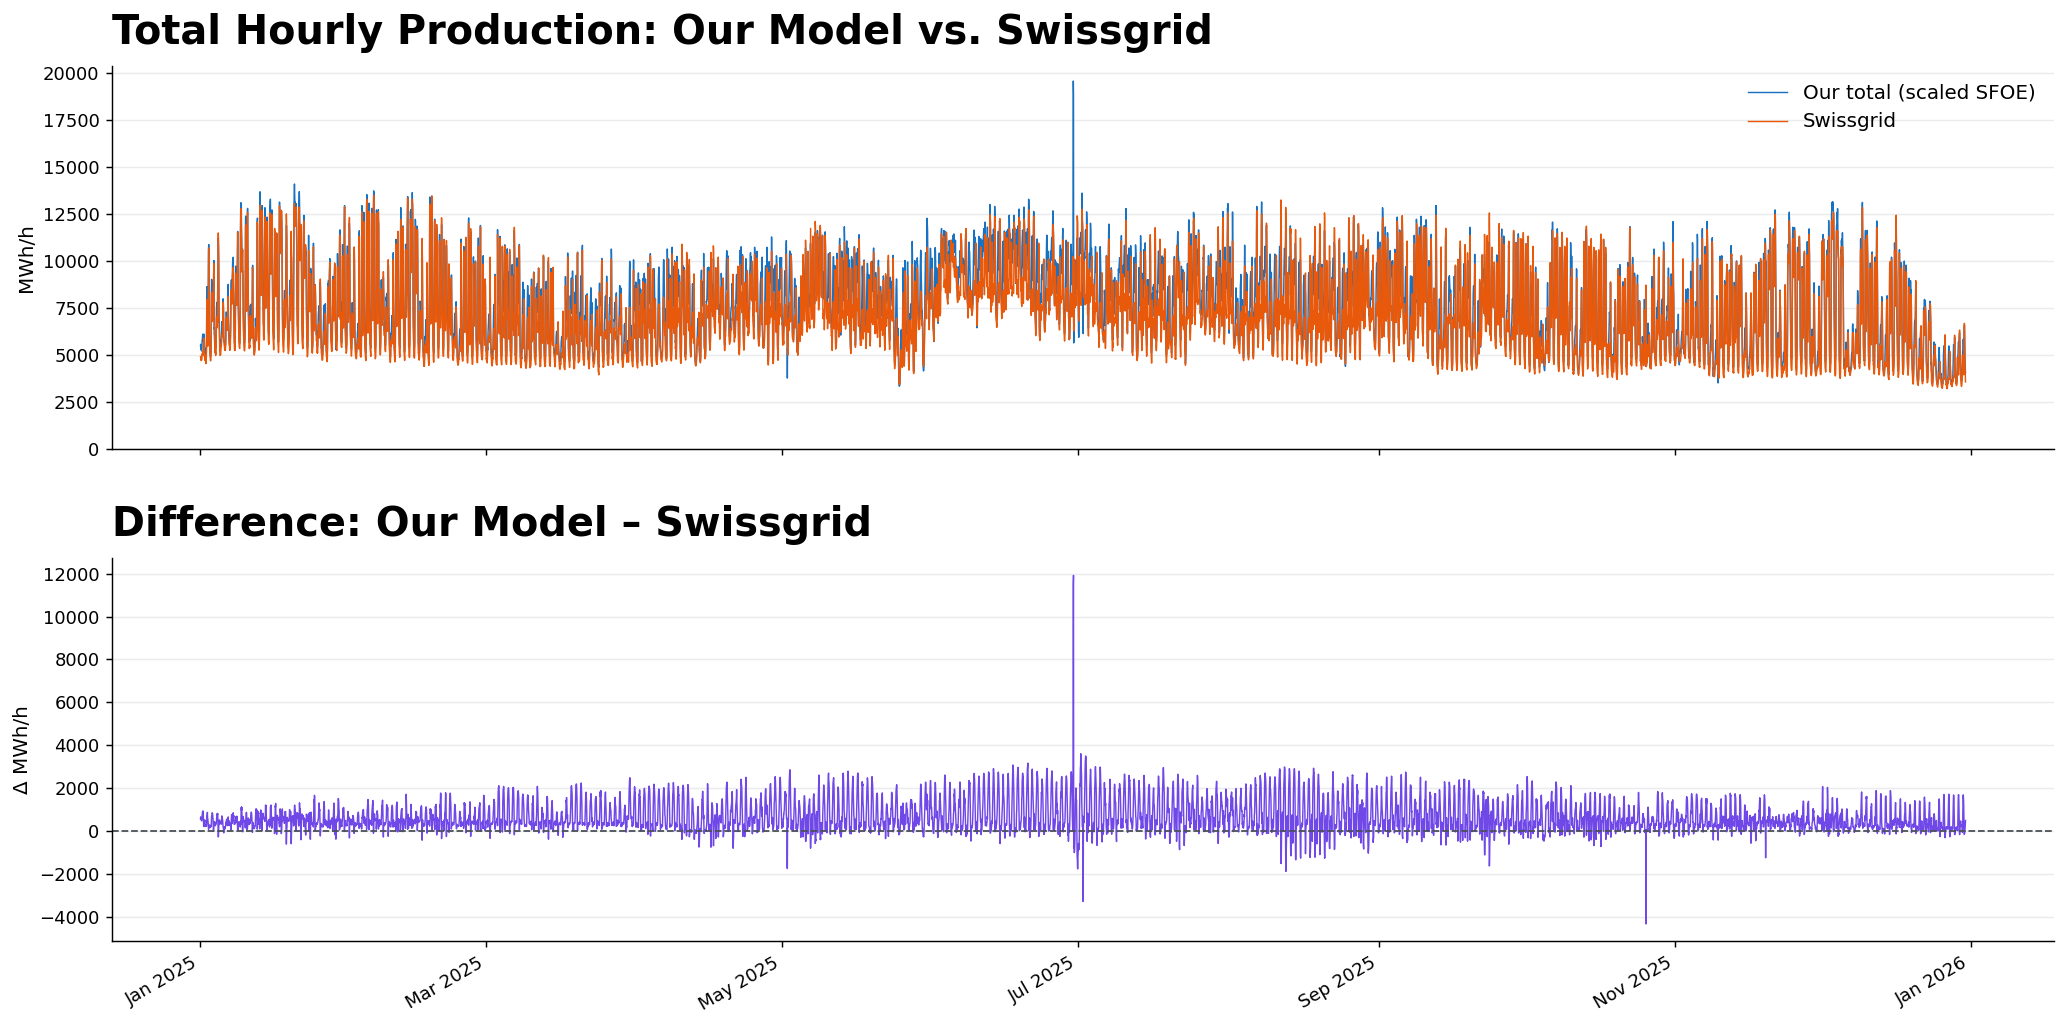

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(common_idx, our_total.values, color='#1971c2', lw=0.8, label='Our total (scaled SFOE)')
axes[0].plot(common_idx, sg_total.values,  color='#e8590c', lw=0.8, label='Swissgrid')
axes[0].set_title('Total Hourly Production: Our Model vs. Swissgrid',
                  fontweight='bold', fontsize=22, loc='left', pad=12)
axes[0].set_ylabel('MWh/h', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', color='#e9ecef', linewidth=0.8)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=11, frameon=False)

axes[1].plot(common_idx, diff.values, color='#7048e8', lw=0.8)
axes[1].axhline(0, color='#495057', lw=1, ls='--')
axes[1].set_title('Difference: Our Model – Swissgrid',
                  fontweight='bold', fontsize=22, loc='left', pad=12)
axes[1].set_ylabel('Δ MWh/h', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', color='#e9ecef', linewidth=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.autofmt_xdate()
plt.tight_layout(h_pad=2.5)
plt.show()

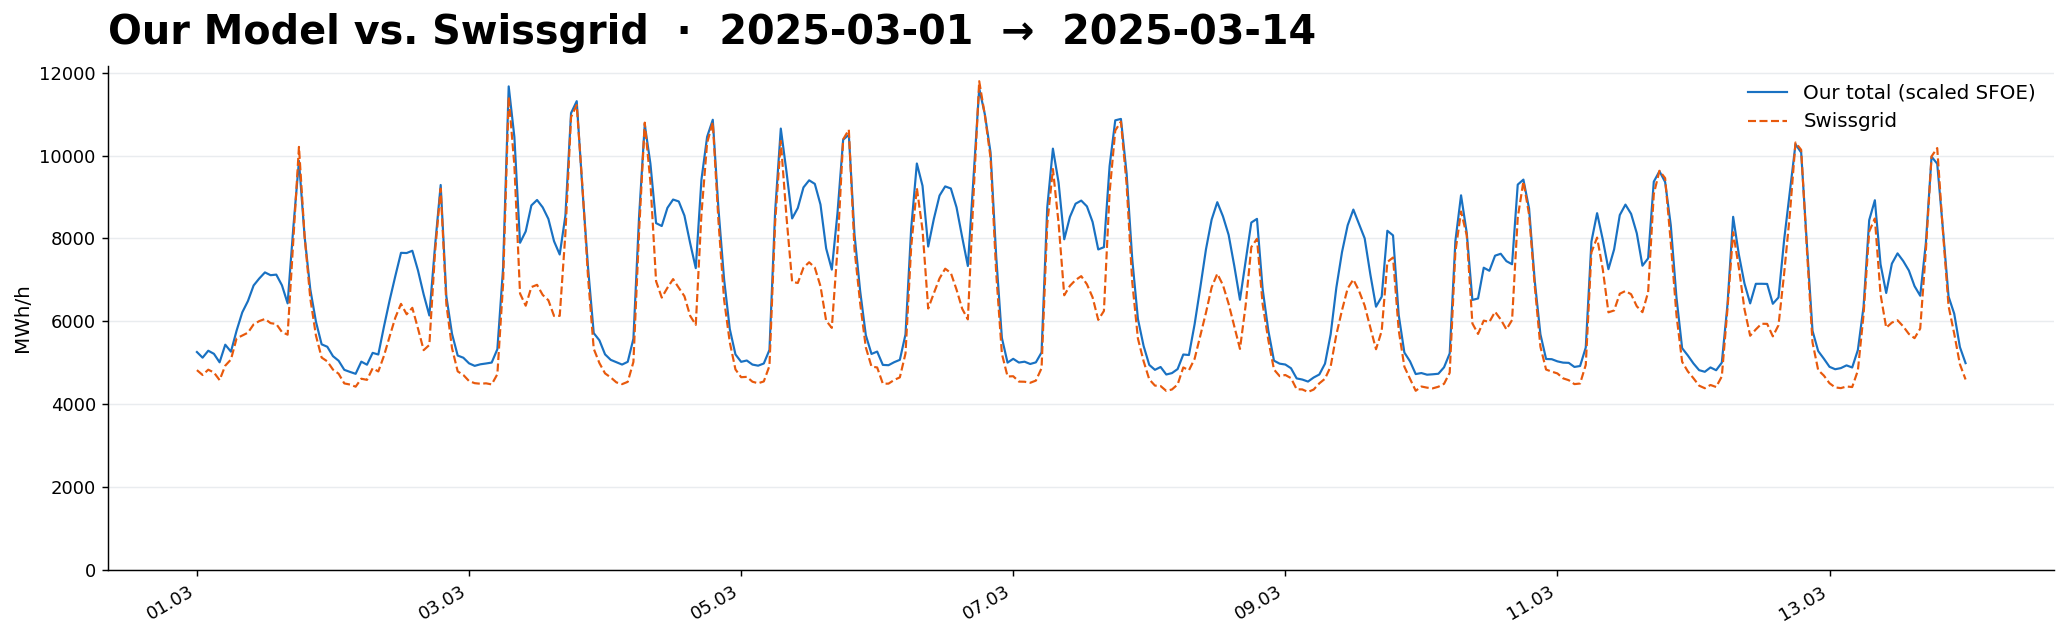

In [24]:
CMP_START = '2025-03-01'
CMP_END   = '2025-03-14'

mask = (common_idx >= CMP_START) & (common_idx <= CMP_END)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(common_idx[mask], our_total[mask],
        color='#1971c2', lw=1.2, label='Our total (scaled SFOE)')
ax.plot(common_idx[mask], sg_total[mask],
        color='#e8590c', lw=1.2, ls='--', label='Swissgrid')

ax.set_title(f'Our Model vs. Swissgrid  ·  {CMP_START}  →  {CMP_END}',
             fontweight='bold', fontsize=22, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

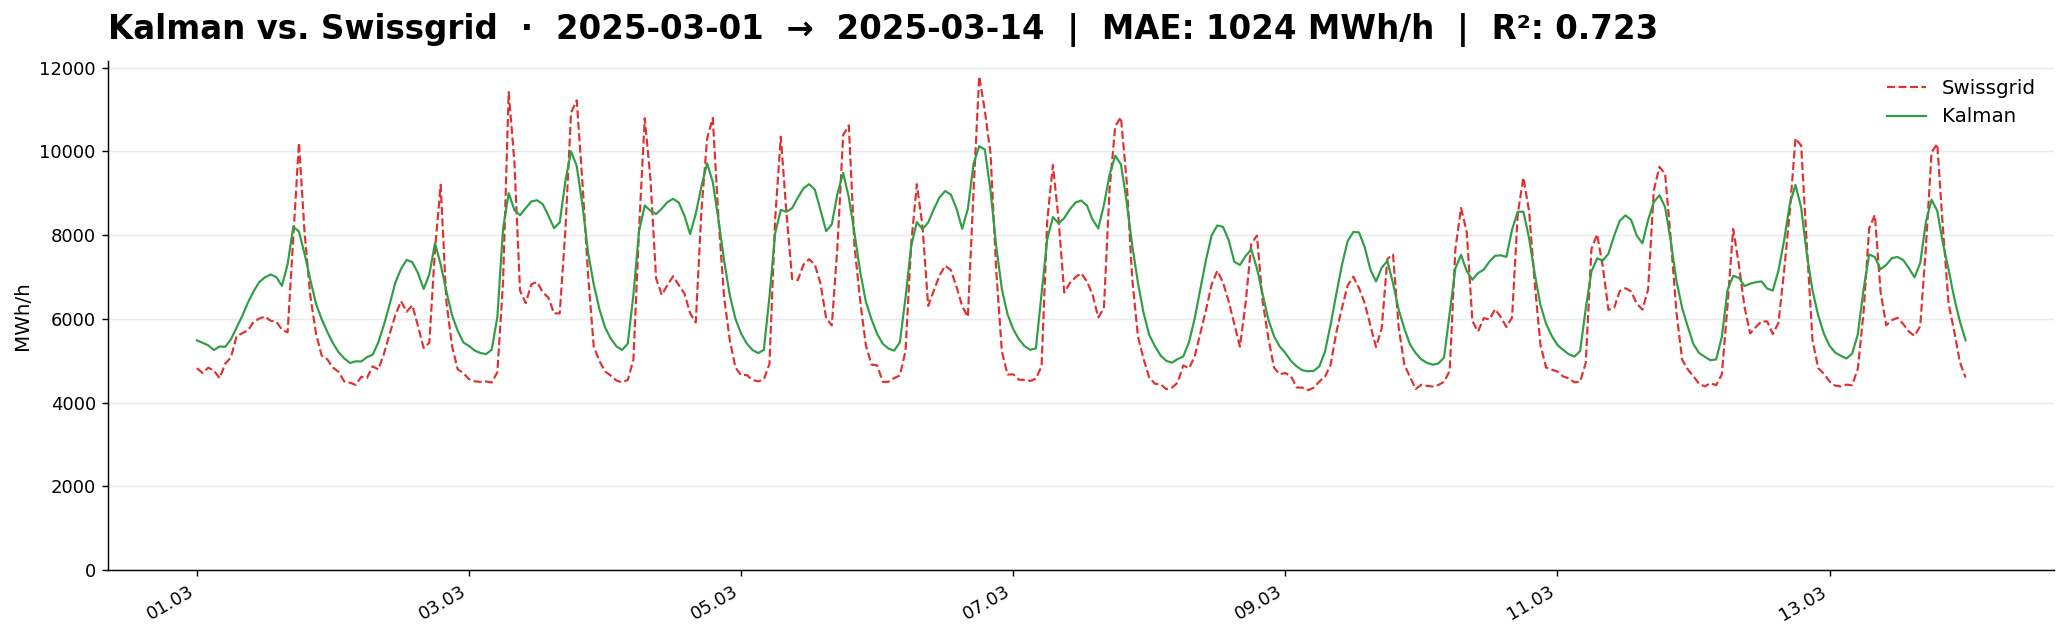

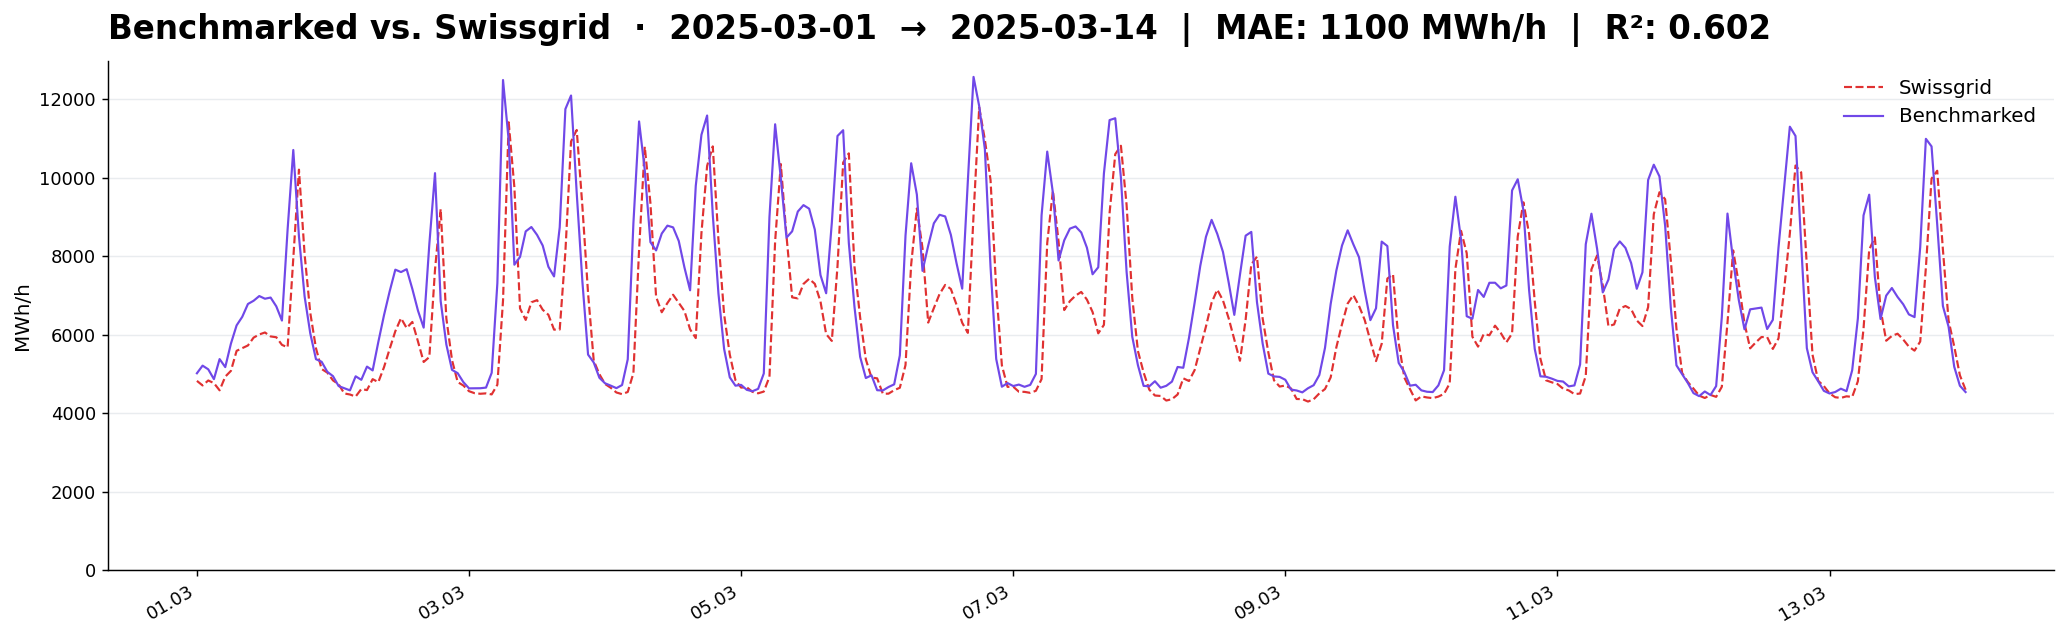

In [29]:
# Load colleague's datasets
CMP_START = '2025-03-01'
CMP_END   = '2025-03-14'

# Kalman (MWh)
kalman = pd.read_csv('data/kalman_hourly_march_week.csv', parse_dates=['DateTime']).set_index('DateTime')
kalman.index = pd.to_datetime(kalman.index)

# Benchmarked (GWh → MWh)
bench = pd.read_csv('data/benchmarked_hourly_march_week.csv', parse_dates=['DateTime']).set_index('DateTime')
bench.index = pd.to_datetime(bench.index)
bench['Sum_Benchmarked'] = bench['Sum_Benchmarked'] * 1000

# Common index
mask_sg  = (swissgrid.index >= CMP_START) & (swissgrid.index <= CMP_END)
sg_zoom  = swissgrid[mask_sg]

common_cmp = sg_zoom.index.intersection(kalman.index).intersection(bench.index)

sg_cmp     = sg_zoom.loc[common_cmp]
kalman_cmp = kalman.loc[common_cmp, 'Sum_Kalman_B']
bench_cmp  = bench.loc[common_cmp, 'Sum_Benchmarked']

# ── Plot 1: Kalman vs. Swissgrid ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(common_cmp, sg_cmp.values,     color='#e03131', lw=1.2, ls='--', label='Swissgrid')
ax.plot(common_cmp, kalman_cmp.values, color='#2f9e44', lw=1.2, label='Kalman')
diff_k = kalman_cmp - sg_cmp
ax.set_title(f'Kalman vs. Swissgrid  ·  {CMP_START}  →  {CMP_END}  '
             f'|  MAE: {diff_k.abs().mean():.0f} MWh/h  |  R²: {kalman_cmp.corr(sg_cmp)**2:.3f}',
             fontweight='bold', fontsize=18, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── Plot 2: Benchmarked vs. Swissgrid ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(common_cmp, sg_cmp.values,    color='#e03131', lw=1.2, ls='--', label='Swissgrid')
ax.plot(common_cmp, bench_cmp.values, color='#7048e8', lw=1.2, label='Benchmarked')
diff_b = bench_cmp - sg_cmp
ax.set_title(f'Benchmarked vs. Swissgrid  ·  {CMP_START}  →  {CMP_END}  '
             f'|  MAE: {diff_b.abs().mean():.0f} MWh/h  |  R²: {bench_cmp.corr(sg_cmp)**2:.3f}',
             fontweight='bold', fontsize=18, loc='left', pad=12)
ax.set_ylabel('MWh/h', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e9ecef', linewidth=0.8)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11, frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

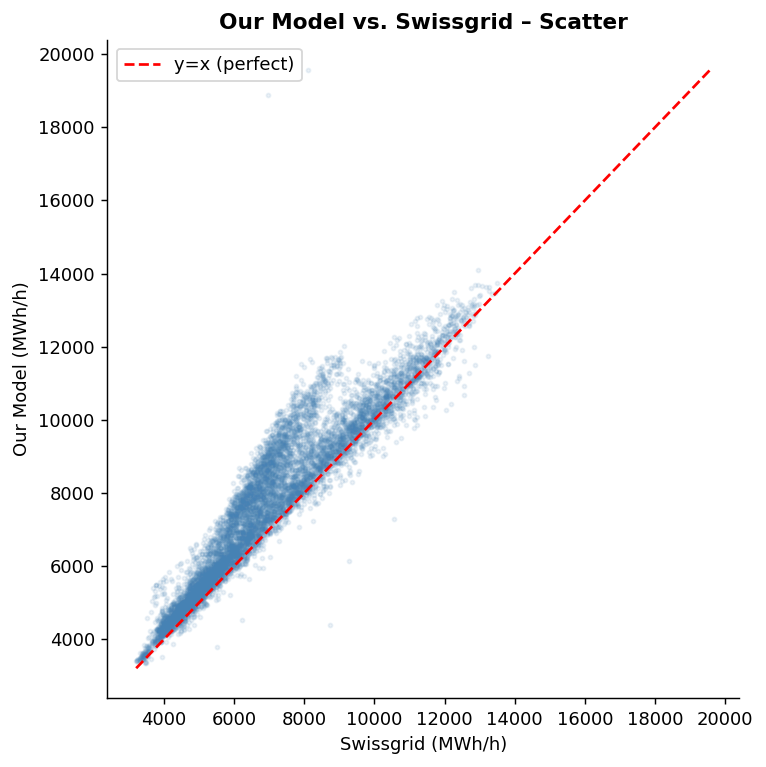

In [26]:
# Plot 3: Scatter Our vs. Swissgrid
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sg_total.values, our_total.values, alpha=0.1, s=5, color='steelblue')
lim = [min(sg_total.min(), our_total.min()), max(sg_total.max(), our_total.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='y=x (perfect)')
ax.set_xlabel('Swissgrid (MWh/h)')
ax.set_ylabel('Our Model (MWh/h)')
ax.set_title('Our Model vs. Swissgrid – Scatter', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Detailed error analysis
from scipy import stats

# Relative error per hour
rel_error = (our_total - sg_total) / sg_total * 100

# Correlation
r, p = stats.pearsonr(our_total, sg_total)

# By month
monthly = pd.DataFrame({'our': our_total, 'sg': sg_total, 'diff': diff})
monthly['month'] = monthly.index.month
monthly_stats = monthly.groupby('month').agg(
    mae=('diff', lambda x: x.abs().mean()),
    mean_diff=('diff', 'mean'),
    rel_error_pct=('diff', lambda x: (x / monthly.loc[x.index, 'sg']).mean() * 100)
).round(1)

print(f'Pearson R:          {r:.4f}  (1.0 = perfect)')
print(f'R²:                 {r**2:.4f}')
print(f'Mean relative err:  {rel_error.mean():.1f}%')
print(f'Median rel. error:  {rel_error.median():.1f}%')
print()
print('Monthly breakdown:')
print(monthly_stats.to_string())

Pearson R:          0.9431  (1.0 = perfect)
R²:                 0.8894
Mean relative err:  10.4%
Median rel. error:  7.5%

Monthly breakdown:
          mae  mean_diff  rel_error_pct
month                                  
1       503.1      486.3            7.0
2       550.9      541.7            8.4
3       717.9      711.7           12.0
4       773.6      735.5           10.5
5       835.0      787.9           11.2
6      1041.6      975.8           11.8
7       997.9      925.2           12.8
8       997.1      831.9           12.6
9       770.4      697.3           10.6
10      628.1      568.5            9.8
11      529.0      503.8            8.8
12      478.0      458.7            8.5


## 9. Conclusion

### Objective
The goal of this project was to build a consistent **hourly power production dataset for Switzerland**, 
disaggregating official SFOE daily totals into hourly resolution using ENTSO-E hourly profiles as shape references 
and the SFOE pv_hourly estimate for photovoltaics.

### Methodology
For each production type and each day, we applied a simple but effective scaling approach:

```
scale_factor[day] = SFOE_daily[day] / sum(profile[day])
hourly_scaled[h]  = profile[h] × scale_factor[day]
```

This guarantees that **daily totals match the official SFOE statistics exactly** (max deviation: 0.000000 GWh), 
while preserving the realistic intra-day variation from the hourly profiles.

The six production types covered are:

| Type | Hourly Profile Source |
|---|---|
| Photovoltaik | SFOE pv_hourly estimate (roof-based solar radiation model) |
| Flusskraft | ENTSO-E Hydro Run-of-river and poundage |
| Kernkraft | ENTSO-E Nuclear |
| Speicherkraft | ENTSO-E Hydro Pumped Storage + Hydro Water Reservoir |
| Wind | ENTSO-E Wind Onshore |
| Thermische | Flat distribution (daily total ÷ 24) |

### Validation against SFOE
All production types were validated against SFOE daily totals. The scaling is mathematically exact: 
the sum of all 24 hourly values for any given day equals the SFOE daily total to floating-point precision.

### Comparison with Swissgrid
The final aggregated hourly dataset was compared against Swissgrid's measured 15-minute transmission data 
(resampled to hourly). Key results:

| Metric | Value |
|---|---|
| Pearson R | 0.943 |
| R² | 0.889 |
| Mean relative error | +10.4% |
| Median relative error | +7.5% |

Our model **systematically overestimates Swissgrid by approximately 10%**. This is expected and not a model error: 
Swissgrid measures production flowing through the high-voltage transmission network, whereas our model captures 
**total national production** — including local self-consumption, direct feed-in to the distribution grid, and 
small decentralised installations that never reach the transmission level.

The seasonal pattern of the error is consistent with this explanation: deviations are largest in summer 
(June–August, ~12–13%) when solar production is high and much of it is consumed locally, and smallest in 
winter (December–January, ~7–8%) when solar output is low.

### Key Takeaways
- The disaggregation approach is **valid and reproducible**: daily SFOE totals are preserved exactly.
- The hourly shape matches Swissgrid well (R²=0.89), confirming that ENTSO-E profiles are suitable shape references.
- The systematic +10% offset reflects a **known structural difference** between total national production and 
transmission-level measurement — not an inaccuracy in the model.
- The resulting dataset enables hourly analysis of Swiss power production for the period 2024–2025, 
fully consistent with official SFOE statistics.
